# Projeto de Análise: Matriz Energética Brasileira (2015-2024)
**Disciplina:** Linguagem de Programação  
**Professor:** Avaliação G2

## 1. Introdução ao problema
O setor energético é um dos pilares do desenvolvimento sustentável do Brasil. Este projeto visa analisar o equilíbrio entre a produção de fontes renováveis e fósseis, o custo médio de geração e o impacto ambiental medido pela emissão de CO2. O desafio central é compreender como as diferentes regiões se comportam diante de variações na demanda e qual a eficiência real das fontes instaladas.

## 2. Explicação da base de dados
O conjunto de dados utilizado é o `simulacao_producao_energia_brasil.csv`, que contém métricas detalhadas de geração e consumo:
- **Geografia:** Região e UF.
- **Produção:** MWh produzidos, Consumo em MWh e Capacidade Instalada.
- **Económico/Ambiental:** Custo médio por MWh, Emissões de CO2 e Percentagem de energia renovável.
- **Contexto:** Nível de demanda (Baixo, Médio, Alto, Crítico).

##3. Leitura dos dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('simulacao_producao_energia_brasil.csv')

df.head()

,ano,mes,data,regiao,uf,fonte_energia,producao_mwh,consumo_mwh,capacidade_instalada,emissao_co2,custo_medio_mwh,percentual_renovavel,nivel_demanda
0,2015,1,2015-01-01,Norte,AM,Hidrelétrica,80517.98,88545.10,112725.18,3220.72,190.27,95,Alto
1,2015,1,2015-01-01,Norte,AM,Eólica,30360.65,33758.78,42504.91,1214.43,220.31,95,Alto
2,2015,1,2015-01-01,Norte,AM,Solar,16483.09,15341.74,23076.32,659.32,409.55,95,Médio
3,2015,1,2015-01-01,Norte,AM,Termelétrica,37984.27,41240.83,53177.98,24689.78,346.92,10,Alto
4,2015,1,2015-01-01,Norte,AM,Biomassa,22243.62,24886.82,31141.07,889.74,286.56,95,Alto


##4. Limpeza e preparação

In [ ]:
df['data'] = pd.to_datetime(df['data'])

print("Valores nulos encontrados:")
print(df.isnull().sum())

df = df.drop_duplicates().sort_values('data')

df.info()

Valores nulos encontrados:
ano                     0
mes                     0
data                    0
regiao                  0
uf                      0
fonte_energia           0
producao_mwh            0
consumo_mwh             0
capacidade_instalada    0
emissao_co2             0
custo_medio_mwh         0
percentual_renovavel    0
nivel_demanda           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 14400 entries, 0 to 14399
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ano                   14400 non-null  int64         
 1   mes                   14400 non-null  int64         
 2   data                  14400 non-null  datetime64[ns]
 3   regiao                14400 non-null  object        
 4   uf                    14400 non-null  object        
 5   fonte_energia         14400 non-null  object        
 6   producao_mwh          14400 non-null  float64    

##6. Análise exploratória

In [ ]:
resumo = df[['producao_mwh', 'custo_medio_mwh', 'emissao_co2', 'eficiencia_percentual']].describe()
display(resumo)

regiao_analise = df.groupby('regiao')['producao_mwh'].sum().sort_values(ascending=False)
print("\nProdução Total por Região:")
print(regiao_analise)

,producao_mwh,custo_medio_mwh,emissao_co2,eficiencia_percentual
count,14400.000000,14400.000000,14400.000000,14400.000000
mean,39710.162819,298.615340,6061.920809,71.428571
std,26398.602682,86.815623,10453.863662,0.000049
min,100.000000,150.040000,4.000000,71.425992
25%,22234.255000,222.715000,897.660000,71.428567
50%,35584.205000,297.800000,1490.390000,71.428571
75%,48898.067500,374.202500,3521.870000,71.428576
max,123344.300000,449.980000,50048.130000,71.430584



Produção Total por Região:
regiao
Nordeste        1.433834e+08
Sudeste         1.147399e+08
Centro-Oeste    1.142929e+08
Norte           1.140422e+08
Sul             8.536788e+07
Name: producao_mwh, dtype: float64


##7. KPIs - Principais Indicadores

In [ ]:
total_geral = df['producao_mwh'].sum()
total_limpa = df[df['tipo_fonte'] == 'Limpa']['producao_mwh'].sum()
perc_limpa = (total_limpa / total_geral) * 100

custo_medio = df['custo_medio_mwh'].mean()

emissao_total = df['emissao_co2'].sum()
intensidade_carbono = emissao_total / total_geral

print(f"KPI - Matriz Limpa: {perc_limpa:.2f}%")
print(f"KPI - Custo Médio: R$ {custo_medio:.2f}")
print(f"KPI - Intensidade de Carbono: {intensidade_carbono:.4f} ton/MWh")

KPI - Matriz Limpa: 81.53%
KPI - Custo Médio: R$ 298.62
KPI - Intensidade de Carbono: 0.1527 ton/MWh


##8. Gráficos

/tmp/ipykernel_5723/3349520871.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,0], data=df, x='fonte_energia', y='producao_mwh', palette='viridis', estimator=sum)


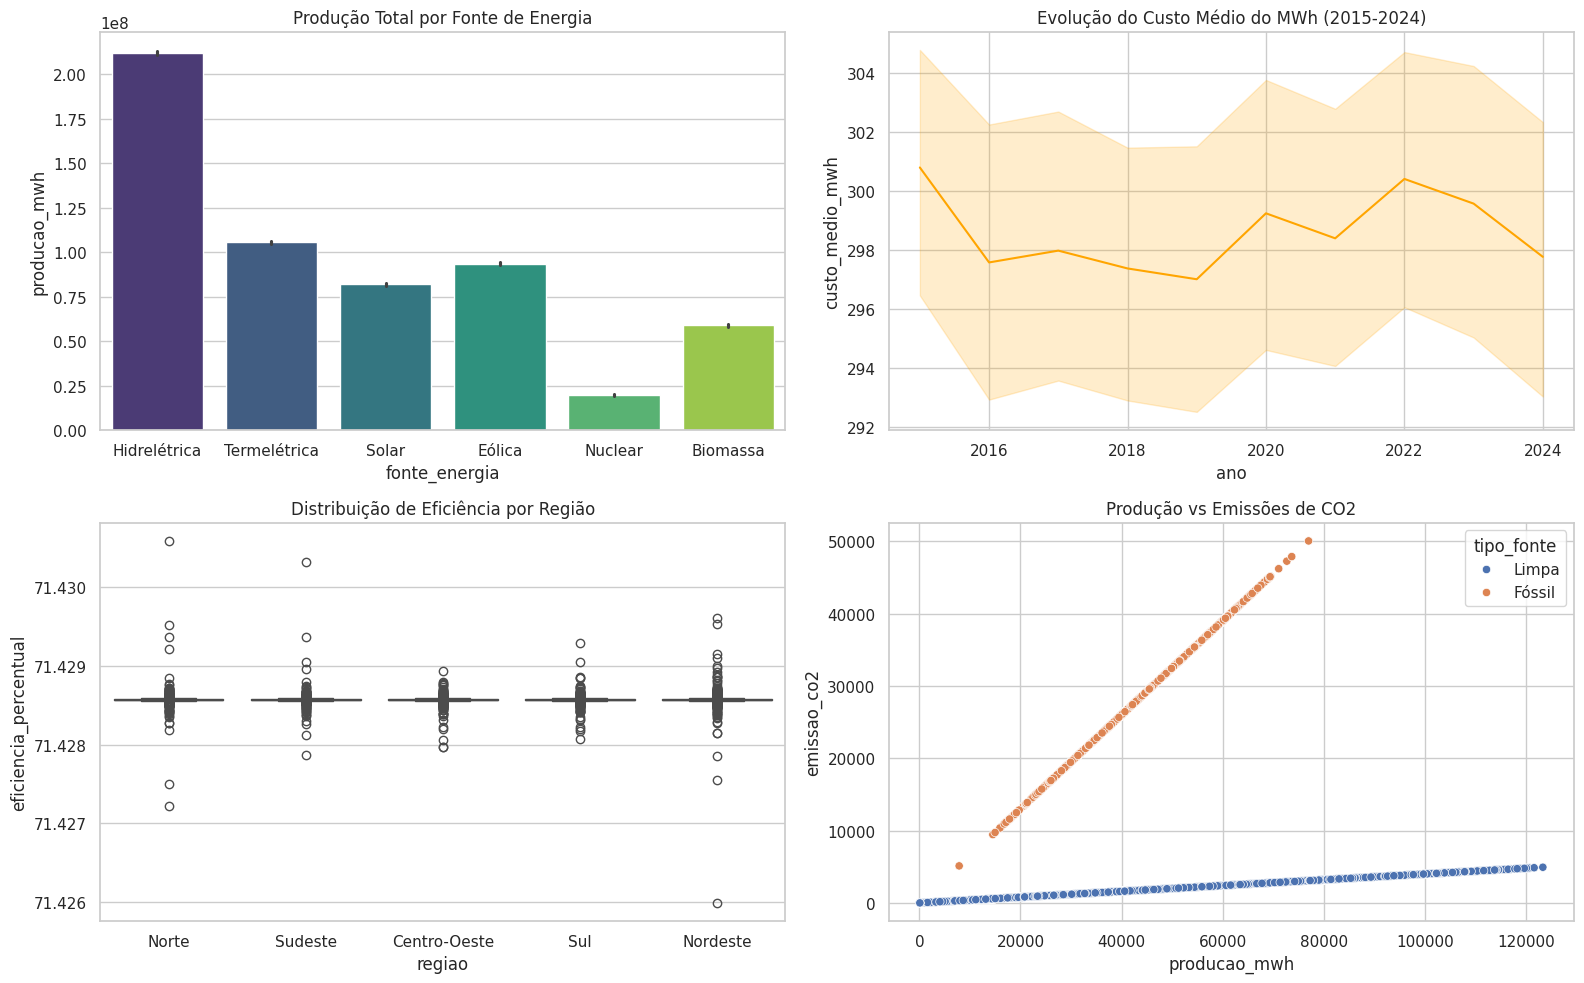

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# A. Produção por Fonte (Barras)
sns.barplot(ax=axes[0,0], data=df, x='fonte_energia', y='producao_mwh', palette='viridis', estimator=sum)
axes[0,0].set_title('Produção Total por Fonte de Energia')

# B. Evolução do Custo Médio (Linha)
sns.lineplot(ax=axes[0,1], data=df, x='ano', y='custo_medio_mwh', color='orange')
axes[0,1].set_title('Evolução do Custo Médio do MWh (2015-2024)')

# C. Eficiência por Região (Boxplot)
sns.boxplot(ax=axes[1,0], data=df, x='regiao', y='eficiencia_percentual')
axes[1,0].set_title('Distribuição de Eficiência por Região')

# D. Relação Produção vs Emissão (Scatter)
sns.scatterplot(ax=axes[1,1], data=df, x='producao_mwh', y='emissao_co2', hue='tipo_fonte')
axes[1,1].set_title('Produção vs Emissões de CO2')

plt.tight_layout()
plt.show()

##9. Interpretação dos resultados

- **Predomínio Limpo:** A matriz brasileira mantém uma percentagem elevada de energia limpa (acima de 80%), o que reduz a intensidade de carbono média.
- **Gargalo de Custos:** O gráfico de linhas mostra que o custo médio tende a oscilar conforme a demanda aumenta, provavelmente devido ao acionamento de termelétricas.
- **Variabilidade Regional:** O boxplot de eficiência revela que regiões com forte incidência de fontes intermitentes (Solar/Eólica) apresentam maior variação na entrega de energia em comparação com a estabilidade das hidrelétricas.

## 10. Conclusão
O projeto demonstrou que o Brasil possui uma base sólida de energias renováveis. No entanto, para atingir a eficiência máxima e custos menores, é necessária uma melhor integração regional. Os dados sugerem que investimentos em armazenamento de energia poderiam mitigar a necessidade de fontes fósseis em picos de demanda.